# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Capstone Project | Fraud Detection</p>

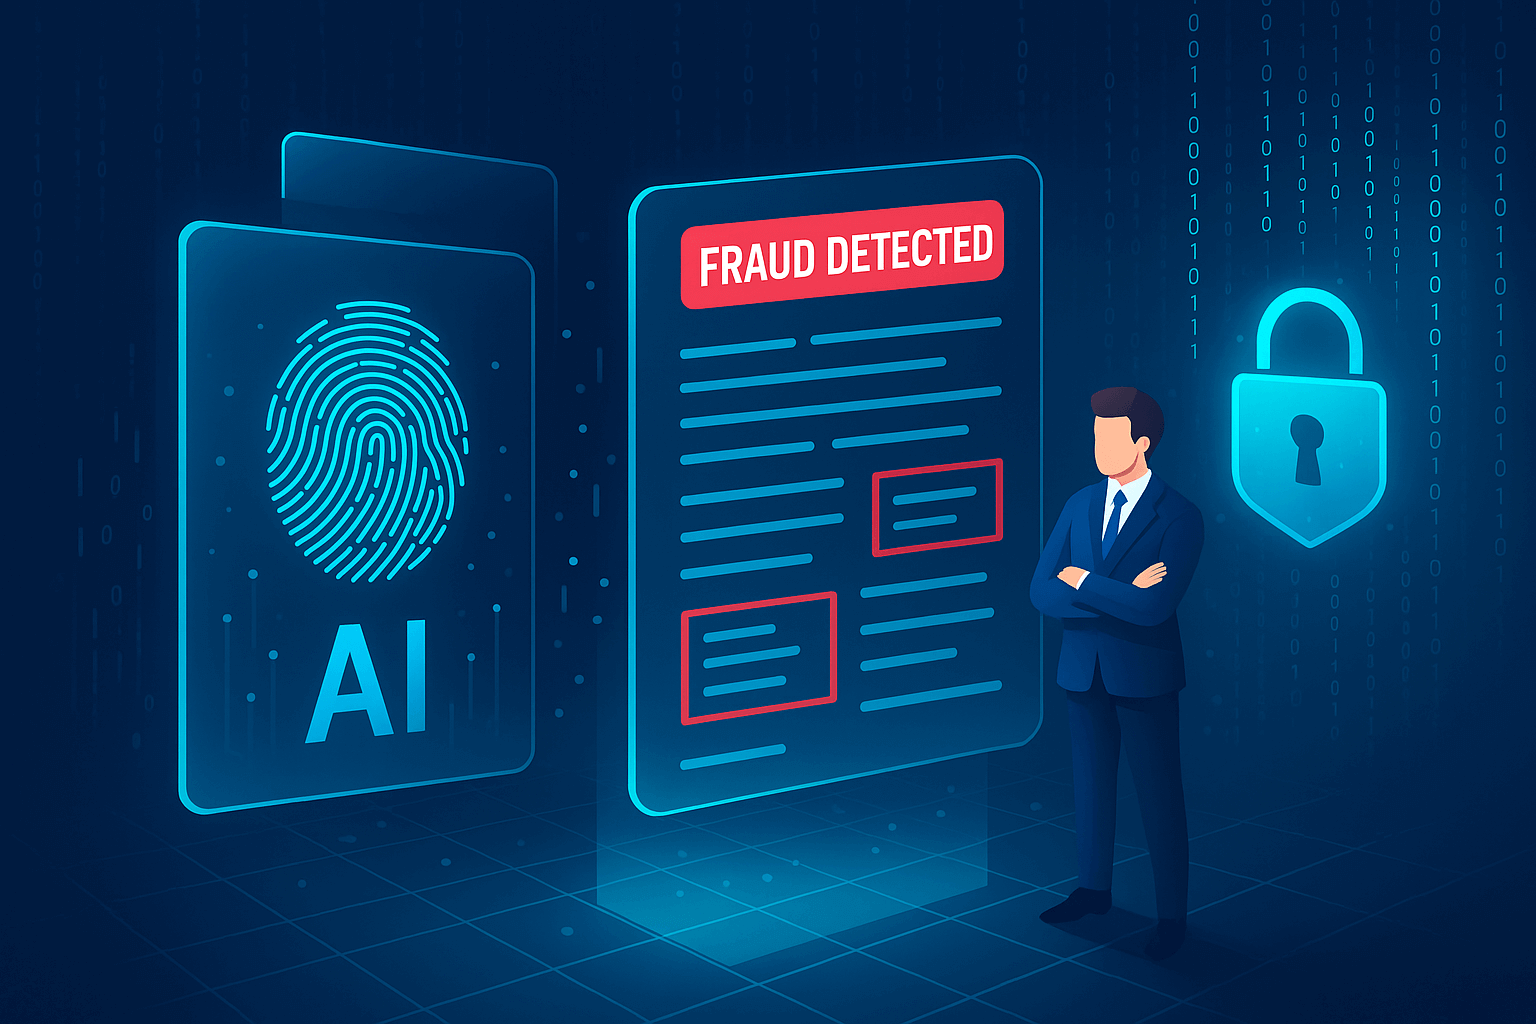

In [1]:
from IPython.display import Image, display
display(Image(filename="C:/Users/yashk/Downloads/FraudDetectionImage.png", width=1400))

<a id="import"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>

⬆️ [Table of Contents](#contents_tabel)

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib

In [3]:
df = pd.read_excel(r'C:\Users\yashk\Downloads\Fraud_Analysis_Dataset.xlsx')

<a id="read"></a>
# <p style="background-color:red ; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>

⬆️ [Table of Contents](#contents_tabel)

In [4]:
df.shape

(11142, 10)

In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


<a id="overview"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset Overview</p>

⬆️ [Table of Contents](#contents_tabel)

In [6]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe(include='object')

,type,nameOrig,nameDest
count,11142,11142,11142
unique,5,11142,7508
top,PAYMENT,C1637966097,C985934102
freq,5510,1,62


<a id="eda"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | EDA</p>

⬆️ [Table of Contents](#contents_tabel)

<Axes: xlabel='isFraud', ylabel='count'>

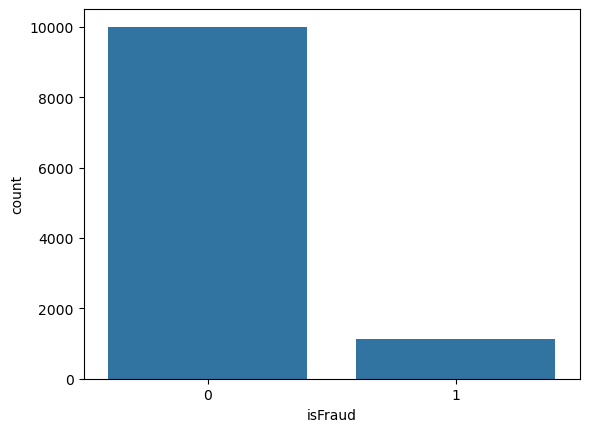

In [11]:
sns.countplot(x='isFraud',data=df)

<Axes: xlabel='type', ylabel='count'>

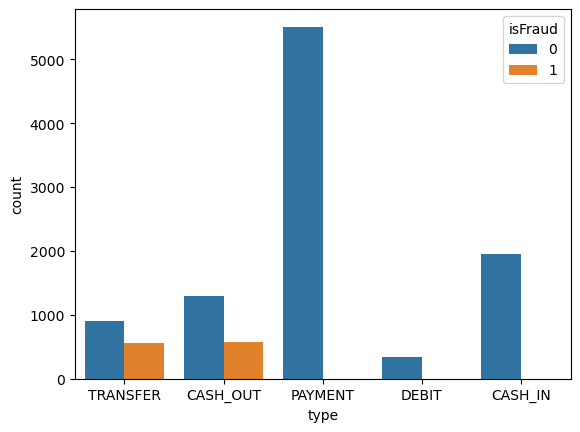

In [12]:
sns.countplot(x='type', hue='isFraud',data=df)

<Axes: xlabel='amount', ylabel='Count'>

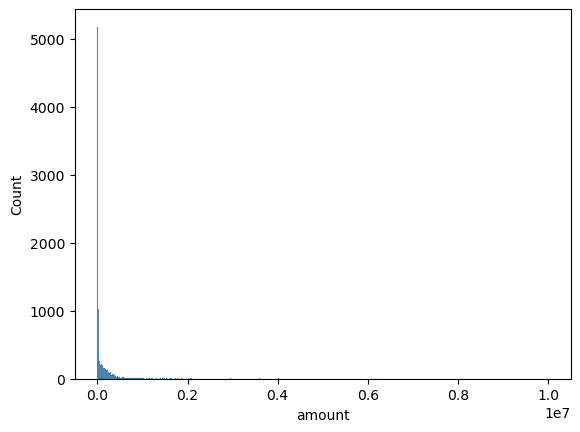

In [13]:
sns.histplot(df['amount'])

<Axes: >

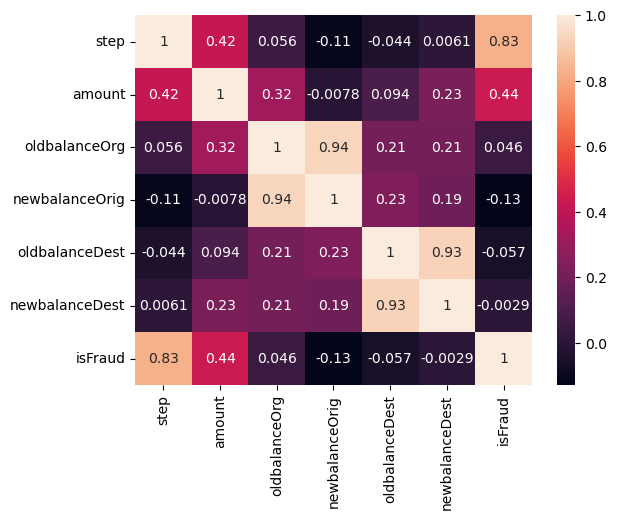

In [14]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<a id="preprocessing"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | Data Preprocessing</p>

⬆️ [Table of Contents](#contents_tabel)

In [15]:
df.rename(columns={
    'step':'transaction_time_step',
    'type':'transaction_type',
    'amount':'transaction_amount',
    'nameOrig':'sender_id',
    'oldbalanceOrg':'sender_balance_before',
    'newbalanceOrig':'sender_balance_after',
    'nameDest':'receiver_id',
    'oldbalanceDest':'receiver_balance_before',
    'newbalanceDest':'receiver_balance_after',
    'isFraud':'fraud_flag'
}, inplace=True)

In [16]:
df.columns

Index(['transaction_time_step', 'transaction_type', 'transaction_amount',
       'sender_id', 'sender_balance_before', 'sender_balance_after',
       'receiver_id', 'receiver_balance_before', 'receiver_balance_after',
       'fraud_flag'],
      dtype='object')

In [17]:
df['balanceDiffOrg'] = df['sender_balance_before'] - df['sender_balance_after']
df['balanceDiffDest'] = df['receiver_balance_after'] - df['receiver_balance_before']

In [18]:
df

,transaction_time_step,transaction_type,transaction_amount,sender_id,sender_balance_before,sender_balance_after,receiver_id,receiver_balance_before,receiver_balance_after,fraud_flag,balanceDiffOrg,balanceDiffDest
0,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,181.00,0.00
1,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,181.00,-21182.00
2,1,TRANSFER,2806.00,C1420196421,2806.00,0.00,C972765878,0.00,0.00,1,2806.00,0.00
3,1,CASH_OUT,2806.00,C2101527076,2806.00,0.00,C1007251739,26202.00,0.00,1,2806.00,-26202.00
4,1,TRANSFER,20128.00,C137533655,20128.00,0.00,C1848415041,0.00,0.00,1,20128.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
11137,7,DEBIT,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0,6393.70,-267885.75
11138,7,CASH_OUT,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0,298799.54,4566008.83
11139,7,CASH_OUT,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0,127891.14,139142.53
11140,7,PAYMENT,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0,1094.03,0.00


In [19]:
df.drop(['sender_id','receiver_id'],axis=1,inplace=True)

In [20]:
encoder = LabelEncoder()

In [21]:
df['transaction_type'] = encoder.fit_transform(df['transaction_type'])

In [22]:
x = df.drop('fraud_flag',axis=1)
y = df['fraud_flag']


x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.80,random_state=42,stratify=y)


<a id="dt"></a>
# <p style="background-color:red; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 6 | Model Evaluation</p>

⬆️ [Table of Contents](#contents_tabel)

In [23]:
lc = LogisticRegression(max_iter=1000)

In [24]:
lc.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [25]:
y_pred_lr = lc.predict(x_test)

In [26]:
print('Accuracy:', accuracy_score(y_test,y_pred_lr))
print('Precision:', precision_score(y_test,y_pred_lr))
print('Recall:', recall_score(y_test,y_pred_lr))
print('f1_score:', f1_score(y_test,y_pred_lr))

Accuracy: 0.9883355764917003
Precision: 0.9809523809523809
Recall: 0.9035087719298246
f1_score: 0.9406392694063926


In [27]:
dt = DecisionTreeClassifier(random_state=42)

In [28]:
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [29]:
y_pred_dt = dt.predict(x_test)

In [30]:
print('Accuracy:', accuracy_score(y_test,y_pred_dt))
print('Precision:', precision_score(y_test,y_pred_dt))
print('Recall:', recall_score(y_test,y_pred_dt))
print('f1_score:', f1_score(y_test,y_pred_dt))

Accuracy: 0.9928218932256617
Precision: 0.9608695652173913
Recall: 0.9692982456140351
f1_score: 0.9650655021834061


In [31]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)

In [32]:
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [33]:
y_pred_rf = rf.predict(x_test)

In [34]:
print('Accuracy:', accuracy_score(y_test,y_pred_rf))
print('Precision:', precision_score(y_test,y_pred_rf))
print('Recall:', recall_score(y_test,y_pred_rf))
print('f1_score:', f1_score(y_test,y_pred_rf))

Accuracy: 0.9959623149394348
Precision: 1.0
Recall: 0.9605263157894737
f1_score: 0.9798657718120806


In [35]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree Classifier',
        'Random Forest'
    ],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf)
    ],
    'Precision':[
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf)
    ],
    'Recall':[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf)
    ],
    'F1 Score':[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_rf)
    ]
})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.988336,0.960870,0.903509,0.940639
1,Decision Tree Classifier,0.992822,0.980952,0.969298,0.965066
2,Random Forest,0.995962,1.000000,0.960526,0.979866


In [36]:
from sklearn.metrics import roc_auc_score

lc_auc = roc_auc_score(
    y_test,
    lc.predict_proba(x_test)[:,1]
)

dt_auc = roc_auc_score(
    y_test,
    dt.predict_proba(x_test)[:,1]
)

rf_auc = roc_auc_score(
    y_test,
    rf.predict_proba(x_test)[:,1]
)

In [37]:
print(lc_auc)
print(dt_auc)
print(rf_auc)

0.9703087052964745
0.9824002472447987
0.99988602190133


In [38]:
cm = confusion_matrix(y_test,y_pred_rf)
print(cm)

[[2001    0]
 [   9  219]]


## GridSearchCV

In [47]:
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10]
}

In [48]:
grid = GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring='f1',n_jobs=-1,verbose=2)

In [49]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1', verbose=2)

In [53]:
print(grid.best_params_)

{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}


In [51]:
print(grid.best_score_)

0.9900243853058855


In [52]:
best_rf = grid.best_estimator_

In [54]:
y_pred_best = best_rf.predict(x_test)

In [55]:
print("Accuracy :", accuracy_score(y_test, y_pred_best))

print("Precision :", precision_score(y_test, y_pred_best))

print("Recall :", recall_score(y_test, y_pred_best))

print("F1 :", f1_score(y_test, y_pred_best))

Accuracy : 0.9959623149394348
Precision : 1.0
Recall : 0.9605263157894737
F1 : 0.9798657718120806


In [56]:
cm_grid = confusion_matrix(y_test,y_pred_best)

In [57]:
cm_grid

array([[2001,    0],
       [   9,  219]])

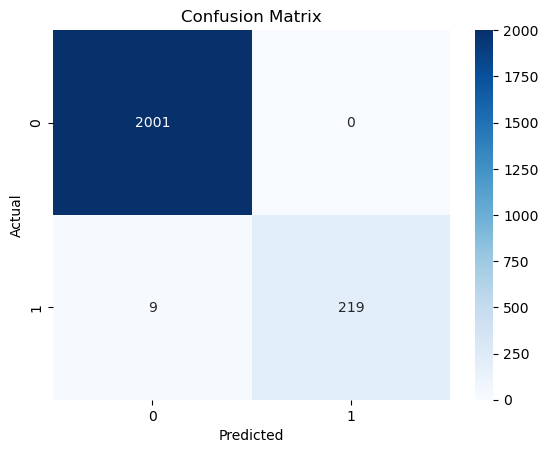

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [60]:
joblib.dump(best_rf,'fraud_detection_model.pkl')

['fraud_detection_model.pkl']

In [61]:
joblib.dump(encoder,'label_encoder.pk1')

['label_encoder.pk1']